<a href="https://colab.research.google.com/github/ddy623/Kaggle-Projects/blob/main/Lifestyle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [3]:
# Load Data
fpath = '/content/drive/MyDrive/Colab Notebooks/Data Science Project/lifestyle weight tracker.csv'
df = pd.read_csv(fpath)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            55000 non-null  int64  
 1   Age                55000 non-null  int64  
 2   Gender             55000 non-null  object 
 3   Height_cm          55000 non-null  float64
 4   Initial_Weight_kg  55000 non-null  float64
 5   Stress_Level       55000 non-null  int64  
 6   Sleep_Hours        55000 non-null  float64
 7   Caffeine_mg        55000 non-null  float64
 8   Calories_Consumed  52250 non-null  float64
 9   Protein_g          55000 non-null  float64
 10  Carbs_g            55000 non-null  float64
 11  Fat_g              55000 non-null  float64
 12  Steps              55000 non-null  int64  
 13  Workout_Type       27448 non-null  object 
 14  Workout_Intensity  55000 non-null  int64  
 15  Temp_C             55000 non-null  float64
 16  Weight_Change      550

In [4]:
df.describe()

,User_ID,Age,Height_cm,Initial_Weight_kg,Stress_Level,Sleep_Hours,Caffeine_mg,Calories_Consumed,Protein_g,Carbs_g,Fat_g,Steps,Workout_Intensity,Temp_C,Weight_Change,Current_Weight_kg
count,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,52250.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000,55000.000000
mean,349.441400,40.918545,169.972335,114.999924,5.524964,6.666340,261.091734,2097.729693,131.073911,235.932955,69.906169,7999.830891,3.496091,24.998172,0.168459,124.480910
std,144.343054,13.539751,9.991794,17.291936,2.881427,1.543146,114.579046,601.919105,37.583689,67.650694,20.044495,89.285148,3.776365,7.992403,0.105259,18.257341
min,100.000000,18.000000,126.190233,85.000325,1.000000,3.000000,0.000000,-327.404484,-20.500000,-36.800000,-10.900000,7632.000000,0.000000,-6.075821,-0.250723,85.327609
25%,224.000000,29.000000,163.273360,100.032148,3.000000,5.610998,181.968341,1693.339924,105.800000,190.500000,56.400000,7939.000000,0.000000,19.609512,0.096170,109.458941
50%,350.000000,41.000000,169.984098,115.032495,6.000000,6.659498,260.645919,2095.328161,130.900000,235.600000,69.800000,7999.000000,0.000000,24.996455,0.168383,124.555885
75%,474.000000,53.000000,176.675947,129.899387,8.000000,7.714812,339.196616,2501.645667,156.300000,281.325000,83.400000,8060.000000,7.000000,30.411654,0.241079,139.369026
max,599.000000,64.000000,213.837588,144.998228,10.000000,11.000000,740.175153,4874.404173,304.700000,548.400000,162.500000,8365.000000,10.000000,58.914302,0.593711,291.842383


In [5]:
df[['Workout_Type', 'Calories_Consumed']].isnull().sum()

,0
Workout_Type,27552
Calories_Consumed,2750


In [6]:
mode_workout_type = df['Workout_Type'].mode()[0]
df['Workout_Type'] = df['Workout_Type'].fillna(mode_workout_type)

median_calories_consumed = df['Calories_Consumed'].median()
df['Calories_Consumed'] = df['Calories_Consumed'].fillna(median_calories_consumed)

df[['Workout_Type', 'Calories_Consumed']].isnull().sum()

,0
Workout_Type,0
Calories_Consumed,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            55000 non-null  int64  
 1   Age                55000 non-null  int64  
 2   Gender             55000 non-null  object 
 3   Height_cm          55000 non-null  float64
 4   Initial_Weight_kg  55000 non-null  float64
 5   Stress_Level       55000 non-null  int64  
 6   Sleep_Hours        55000 non-null  float64
 7   Caffeine_mg        55000 non-null  float64
 8   Calories_Consumed  55000 non-null  float64
 9   Protein_g          55000 non-null  float64
 10  Carbs_g            55000 non-null  float64
 11  Fat_g              55000 non-null  float64
 12  Steps              55000 non-null  int64  
 13  Workout_Type       55000 non-null  object 
 14  Workout_Intensity  55000 non-null  int64  
 15  Temp_C             55000 non-null  float64
 16  Weight_Change      550

In [8]:


# Convert 'Gender' to numerical for correlation calculation
df_numeric = df.copy()
df_numeric['Gender'] = df_numeric['Gender'].map({'Female': 0, 'Male': 1})

# Select only numeric columns for correlation calculation
numeric_cols = df_numeric.select_dtypes(include=['number']).columns
correlation_matrix = df_numeric[numeric_cols].corr()

# Correlations with Gender
print("\nCorrelations with Gender:")
print(correlation_matrix['Gender'].drop('Gender').sort_values(ascending=False))

# Correlations with Age
print("\nCorrelations with Age:")
print(correlation_matrix['Age'].drop('Age').sort_values(ascending=False))


Correlations with Gender:
Temp_C               0.002399
Steps                0.002020
Age                  0.001485
Carbs_g              0.000853
Fat_g                0.000852
Protein_g            0.000851
Calories_Consumed    0.000763
Caffeine_mg          0.000299
Weight_Change       -0.000274
User_ID             -0.000369
Initial_Weight_kg   -0.001521
Sleep_Hours         -0.001959
Current_Weight_kg   -0.002750
Stress_Level        -0.003291
Height_cm           -0.004113
Workout_Intensity   -0.008611
Name: Gender, dtype: float64

Correlations with Age:
Workout_Intensity    0.005091
Steps                0.004754
Caffeine_mg          0.003404
Gender               0.001485
Sleep_Hours          0.000773
Stress_Level        -0.001699
Current_Weight_kg   -0.002368
Fat_g               -0.002412
Protein_g           -0.002417
Carbs_g             -0.002419
Height_cm           -0.002787
Initial_Weight_kg   -0.002807
Calories_Consumed   -0.003352
User_ID             -0.003988
Weight_Change       

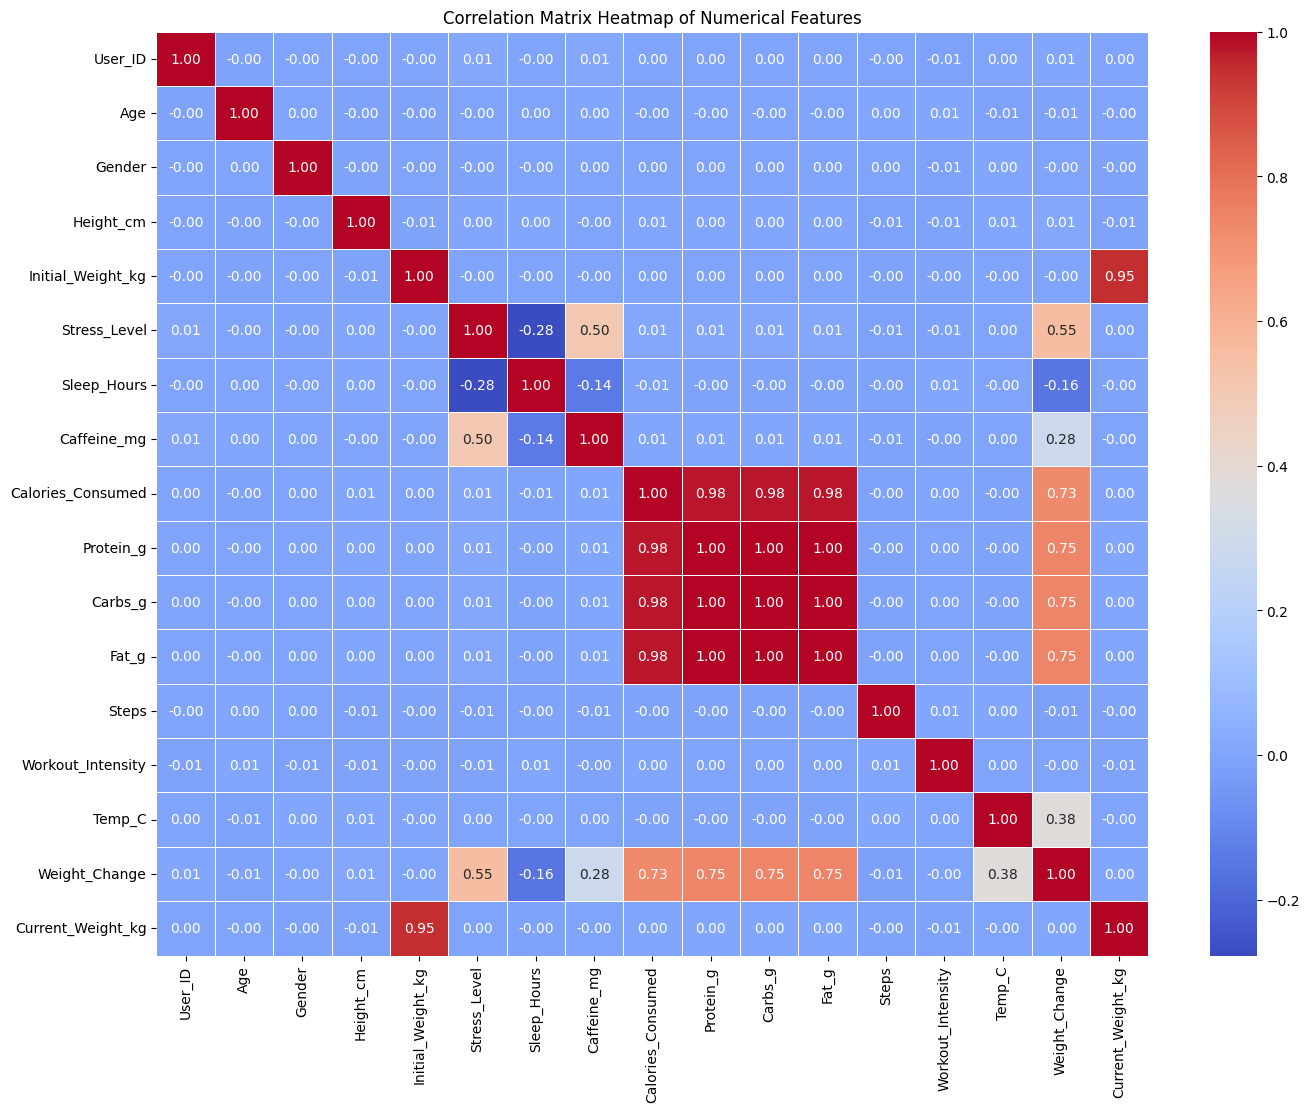

In [9]:
plt.figure(figsize=(16, 12)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix Heatmap of Numerical Features')
plt.show()

Based on the correlation matrix and heatmap, the highest correlations are observed among protein, carbs, and fat. Data show an almost positive correlation, suggesting that the nutritional componets tend to increase or decrease together in similar proportions.

The data also show a positive correlation with stress level and caffeine, which means higher stress levels tend to be assocated with higher caffeine intake.

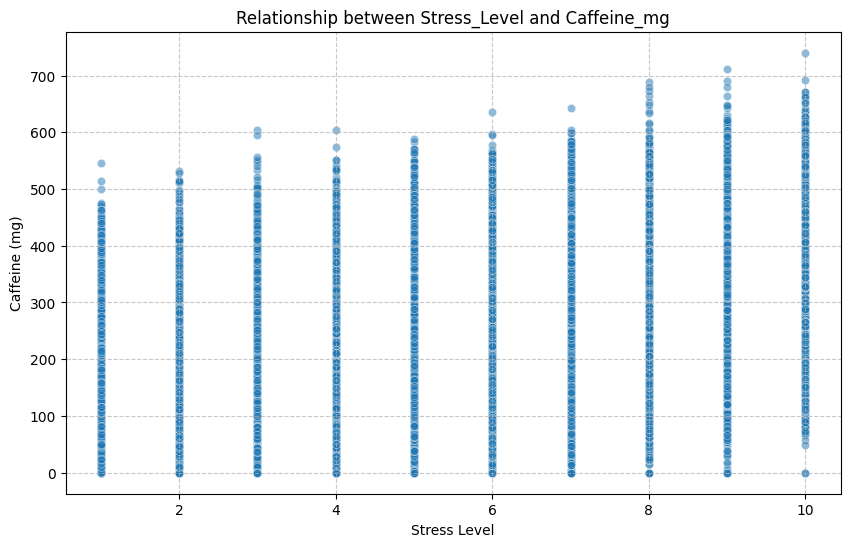

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Stress_Level', y='Caffeine_mg', alpha=0.5)
plt.title('Relationship between Stress_Level and Caffeine_mg')
plt.xlabel('Stress Level')
plt.ylabel('Caffeine (mg)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

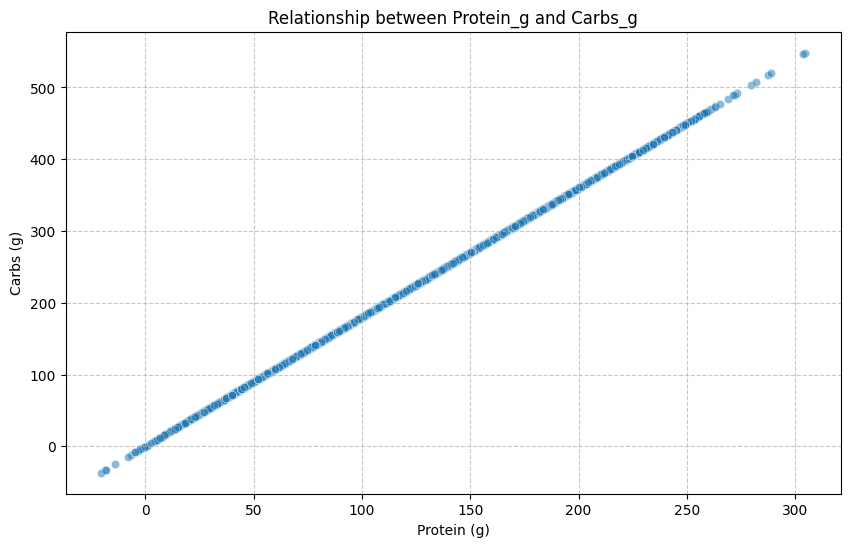

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Protein_g', y='Carbs_g', alpha=0.5)
plt.title('Relationship between Protein_g and Carbs_g')
plt.xlabel('Protein (g)')
plt.ylabel('Carbs (g)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

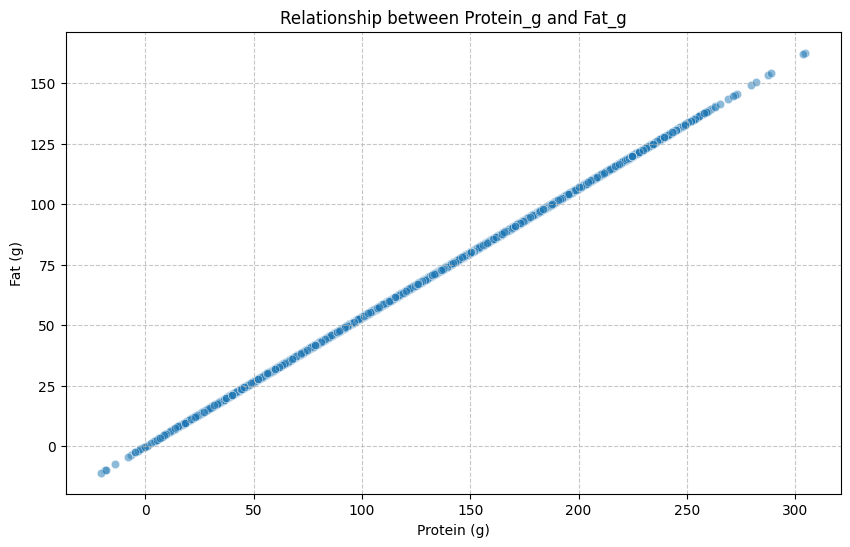

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Protein_g', y='Fat_g', alpha=0.5)
plt.title('Relationship between Protein_g and Fat_g')
plt.xlabel('Protein (g)')
plt.ylabel('Fat (g)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

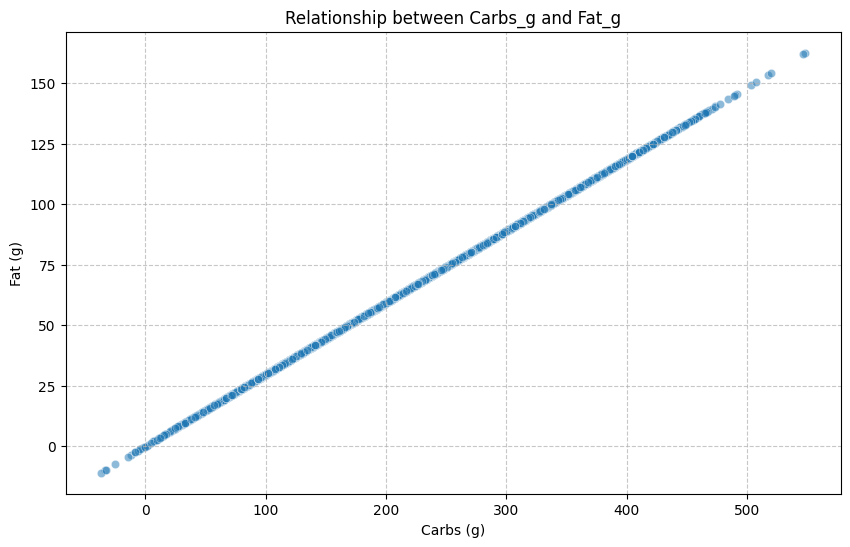

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Carbs_g', y='Fat_g', alpha=0.5)
plt.title('Relationship between Carbs_g and Fat_g')
plt.xlabel('Carbs (g)')
plt.ylabel('Fat (g)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

When it comes to weakest correlation,gender and age showed a weak correlation.  There was also a weak correlation for stress level and workout intensity.

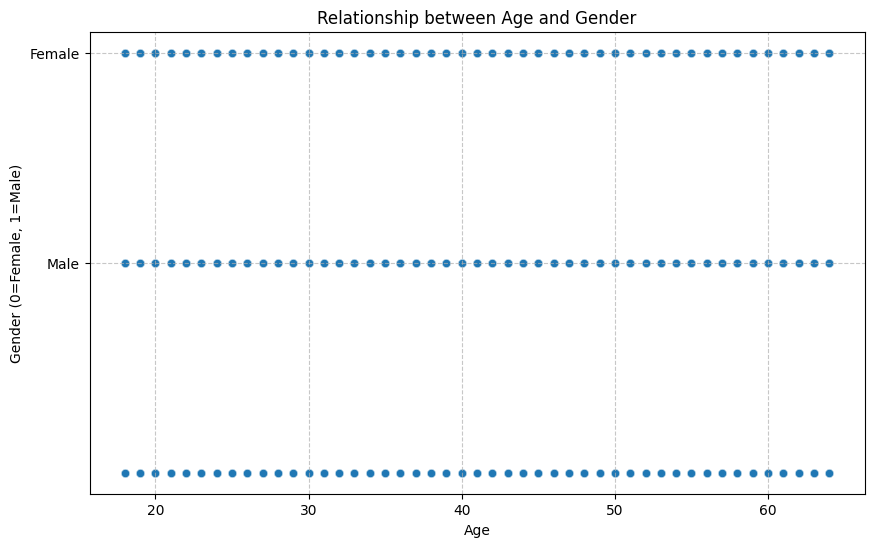

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Gender', alpha=0.5)
plt.title('Relationship between Age and Gender')
plt.xlabel('Age')
plt.ylabel('Gender (0=Female, 1=Male)')
plt.yticks([0, 1], ['Female', 'Male']) # Set custom y-axis ticks and labels
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

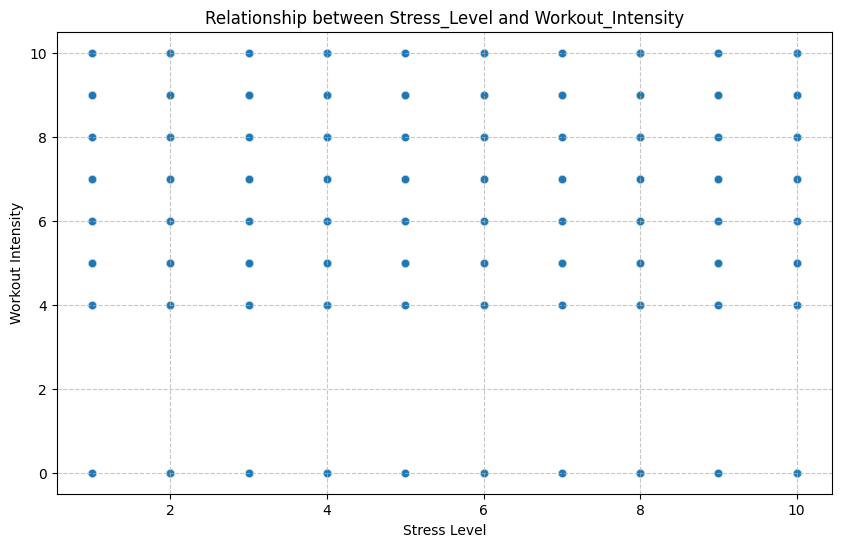

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Stress_Level', y='Workout_Intensity', alpha=0.5)
plt.title('Relationship between Stress_Level and Workout_Intensity')
plt.xlabel('Stress Level')
plt.ylabel('Workout Intensity')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Machine Learning: Regression Task (Predicting Weight Change)

To predict `Weight_Change`, we'll follow these steps:
1.  **Feature Engineering**: Convert categorical features to numerical representations.
2.  **Data Splitting**: Divide the dataset into training and testing sets.
3.  **Model Training**: Use a Linear Regression model to learn from the training data.
4.  **Model Evaluation**: Assess the model's performance on the test data.

In [16]:

# Make a copy to avoid modifying the original DataFrame directly
df_ml = df.copy()

# Encode 'Gender' and 'Workout_Type' categorical features
le_gender = LabelEncoder()
df_ml['Gender_encoded'] = le_gender.fit_transform(df_ml['Gender'])

# Handle 'Workout_Type' (it was filled with 'Cardio' for missing values)
le_workout = LabelEncoder()
df_ml['Workout_Type_encoded'] = le_workout.fit_transform(df_ml['Workout_Type'])

# Define features (X) and target (y)
# We'll drop original categorical columns and User_ID, and the target variable itself
X = df_ml.drop(['User_ID', 'Gender', 'Workout_Type', 'Weight_Change', 'Current_Weight_kg'], axis=1)
y = df_ml['Weight_Change']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("Features used:", X.columns.tolist())

Features (X) shape: (55000, 15)
Target (y) shape: (55000,)
Features used: ['Age', 'Height_cm', 'Initial_Weight_kg', 'Stress_Level', 'Sleep_Hours', 'Caffeine_mg', 'Calories_Consumed', 'Protein_g', 'Carbs_g', 'Fat_g', 'Steps', 'Workout_Intensity', 'Temp_C', 'Gender_encoded', 'Workout_Type_encoded']


Now, we will split the data into training and testing sets. This allows us to train our model on one portion of the data and evaluate its performance on unseen data.

In [17]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 44000 samples
Test set size: 11000 samples


Next, we'll initialize and train a simple Linear Regression model, which is a good baseline for regression tasks.

In [18]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


Finally, we evaluate the model's performance on the test set using metrics like Mean Squared Error (MSE) and R-squared (R2).

In [19]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

Mean Squared Error (MSE): 0.0000
R-squared (R2): 1.0000


The results suggest that the linear regression model was able to predict weight change with a very high accuracy on the dataset.

### Machine Learning: Classification Task (Predicting Workout Type)

Now, we will perform a classification task to predict the `Workout_Type`. The steps will be similar to the regression task, but we will adjust for a categorical target and use classification-specific models and evaluation metrics.

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make a copy for classification task
df_clf = df.copy()

# Encode 'Gender' for features if not already done in df_clf (df_ml had it, but df_clf is a fresh copy)
le_gender_clf = LabelEncoder()
df_clf['Gender_encoded'] = le_gender_clf.fit_transform(df_clf['Gender'])

# Encode 'Workout_Type' as the target variable
le_workout_target = LabelEncoder()
df_clf['Workout_Type_encoded'] = le_workout_target.fit_transform(df_clf['Workout_Type'])

# Define features (X_clf) and target (y_clf)
# Drop original categorical columns, User_ID, and the regression target/its encoded version
X_clf = df_clf.drop(['User_ID', 'Gender', 'Workout_Type', 'Workout_Type_encoded', 'Weight_Change', 'Current_Weight_kg'], axis=1)
y_clf = df_clf['Workout_Type_encoded']

print("Features (X_clf) shape:", X_clf.shape)
print("Target (y_clf) shape:", y_clf.shape)
print("Features used:", X_clf.columns.tolist())
print("Target classes:", le_workout_target.classes_)

Features (X_clf) shape: (55000, 14)
Target (y_clf) shape: (55000,)
Features used: ['Age', 'Height_cm', 'Initial_Weight_kg', 'Stress_Level', 'Sleep_Hours', 'Caffeine_mg', 'Calories_Consumed', 'Protein_g', 'Carbs_g', 'Fat_g', 'Steps', 'Workout_Intensity', 'Temp_C', 'Gender_encoded']
Target classes: ['Cardio' 'Strength' 'Yoga']


Next, we split the data into training and testing sets to properly evaluate our classification model.

In [21]:
# Split data into training and testing sets for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf) # stratify for balanced classes

print(f"Training set size: {len(X_train_clf)} samples")
print(f"Test set size: {len(X_test_clf)} samples")

Training set size: 44000 samples
Test set size: 11000 samples


We will use a RandomForestClassifier, which is a powerful and versatile model for classification tasks. It can capture complex relationships in the data.

In [22]:
# Initialize and train the RandomForestClassifier model
clf_model = RandomForestClassifier(n_estimators=100, random_state=42)
clf_model.fit(X_train_clf, y_train_clf)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


Finally, we evaluate the classification model's performance on the test set using metrics such as accuracy, precision, recall, F1-score, and a confusion matrix.

Accuracy: 0.7022

Classification Report:
              precision    recall  f1-score   support

      Cardio       0.80      0.86      0.83      7706
    Strength       0.40      0.49      0.44      2195
        Yoga       0.20      0.01      0.01      1099

    accuracy                           0.70     11000
   macro avg       0.47      0.45      0.43     11000
weighted avg       0.66      0.70      0.67     11000


Confusion Matrix:


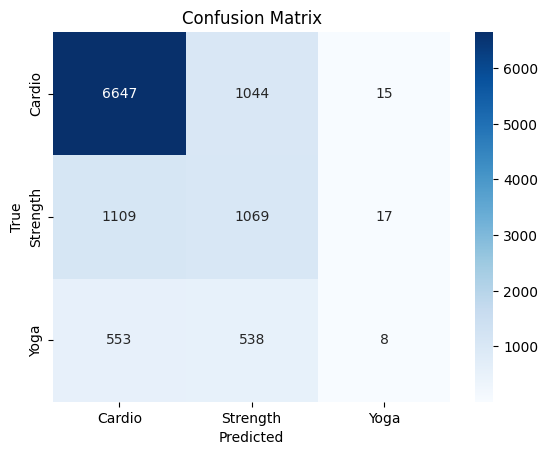

In [23]:
# Make predictions on the test set
y_pred_clf = clf_model.predict(X_test_clf)

# Evaluate the model
accuracy = accuracy_score(y_test_clf, y_pred_clf)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_clf, y_pred_clf, target_names=le_workout_target.classes_))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test_clf, y_pred_clf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_workout_target.classes_, yticklabels=le_workout_target.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In summary, the model performs quite well for Cardio, moderately for Strength, and very poor for Yoga.